# RadIAnce: Parametric Roof Irradiance Emulation Framework

In this notebook, you will develop an emulator for the annual irradiance and surface area of a parametric roof. The roof geometry is characterized by eight predefined geometric parameters. A computational model has been used to evaluate the yearly irradiance on a mesh discretization of the reconstructed roof; the outputs may therefore be affected by numerical errors.
The goal is to enable efficient solar potential assessment for energy systems analysis and design optimization.

Using Monte Carlo sampling, a dataset has been constructed consisting of 20000 parameter instances and their corresponding two-dimensional outputs. The data are provided in the file `SCTdata20K.csv`.

Note that the ranges of the eight parameters are defined in the following array:

In [37]:
import numpy as np
ranges = np.array([
    [0,5],  #p1
    [0,10], #p2
    [0,5],  #p3
    [0,4],  #p4
    [0,4],  #p5
    [0,4],  #p6
    [3,13], #p7
    [1,7],  #p8
])

## Load data

In [38]:
import numpy as np

data = np.genfromtxt('SCTdata20K.csv', delimiter=';', skip_header=0)
print(f"Data shape: {data.shape}")

Data shape: (20000, 10)


In [39]:
# Separate inputs (8 geometric parameters) and outputs (area, irradiance).
num_params = 8

params = data[:, :num_params].astype(np.float32)
output = data[:, num_params:].astype(np.float32)

# Convert irradiance to MWh/year.
output[:, 1] = output[:, 1] * 1e3

# Signature of the function

You are required to implement the function `checkpoint_implementation(params)`, which implement the surrogate model. 

The input argument params is a NumPy array of shape (num_samples, 8), where each row represents a roof configuration defined by the eight geometric parameters. The function must work for an arbitrary number of samples.

The function should return a NumPy array predicted_output with shape (num_samples, 2), matching the structure of the reference outputs provided in the dataset. The second column must contain the predicted annual irradiance, and the first column must contain the predicted roof surface area. 

We found the best performance by testing the given data with the Random Forest Model, below is the implementation of the applicable function `checkpoint_implementation(params)`

In [40]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Use float32 to reduce memory and speed up fit/predict.
train_params = np.asarray(params, dtype=np.float32)
train_output = np.asarray(output, dtype=np.float32)

In [41]:
# Compact forest for faster inference with good accuracy.
rf_model = RandomForestRegressor(
        n_estimators=32,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
)
rf_model.fit(train_params, train_output)

def checkpoint_implementation(params):
    params = np.asarray(params, dtype=np.float32)

    if params.ndim == 1:
        params = params.reshape(1, -1)

    if params.shape[1] != 8:
        raise ValueError(f"Expected input shape (num_samples, 8), got {params.shape}")

    predicted_output = rf_model.predict(params).astype(np.float32, copy=False)
    return predicted_output

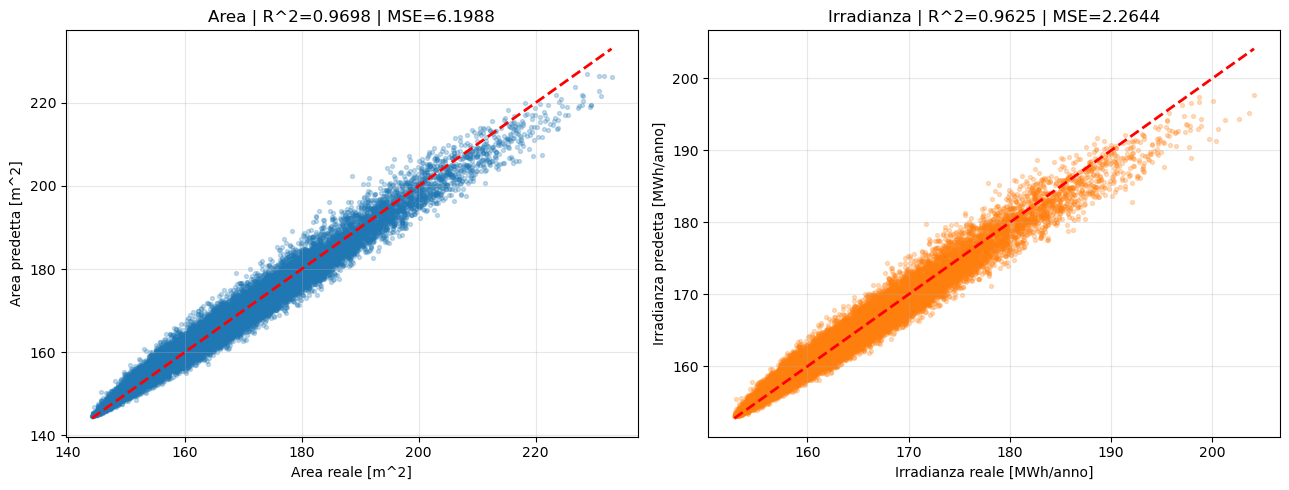

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Quick diagnostic plot: if points lie near y=x, RF is performing well.
y_pred = checkpoint_implementation(params)

r2_area = r2_score(output[:, 0], y_pred[:, 0])
r2_irr = r2_score(output[:, 1], y_pred[:, 1])
mse_area = mean_squared_error(output[:, 0], y_pred[:, 0])
mse_irr = mean_squared_error(output[:, 1], y_pred[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Area plot
ax[0].scatter(output[:, 0], y_pred[:, 0], s=8, alpha=0.25, color='tab:blue')
mn0 = min(output[:, 0].min(), y_pred[:, 0].min())
mx0 = max(output[:, 0].max(), y_pred[:, 0].max())
ax[0].plot([mn0, mx0], [mn0, mx0], 'r--', lw=2)
ax[0].set_xlabel('Area reale [m^2]')
ax[0].set_ylabel('Area predetta [m^2]')
ax[0].set_title(f'Area | R^2={r2_area:.4f} | MSE={mse_area:.4f}')
ax[0].grid(True, alpha=0.3)

# Irradiance plot
ax[1].scatter(output[:, 1], y_pred[:, 1], s=8, alpha=0.25, color='tab:orange')
mn1 = min(output[:, 1].min(), y_pred[:, 1].min())
mx1 = max(output[:, 1].max(), y_pred[:, 1].max())
ax[1].plot([mn1, mx1], [mn1, mx1], 'r--', lw=2)
ax[1].set_xlabel('Irradianza reale [MWh/anno]')
ax[1].set_ylabel('Irradianza predetta [MWh/anno]')
ax[1].set_title(f'Irradianza | R^2={r2_irr:.4f} | MSE={mse_irr:.4f}')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()